题目：
构造一个用于二分类的简单神经网络，网络结构如下：

输入层：2 个特征

隐藏层：2 个神经元，激活函数为 Tanh

输出层：2 个神经元，激活函数在计算损失时使用 Softmax（PyTorch 的 CrossEntropyLoss 已经包含了 softmax）

给定数据：

一个训练样本：

python
复制
编辑
X = torch.tensor([[1.0, -1.0]])      # shape = [1, 2]
y_true = torch.tensor([1])           # 类别标签 1（第二类）
参数初始化（均需 requires_grad=True）：

python
复制
编辑
W1 = torch.tensor([[0.1, 0.2],
                   [0.3, 0.4]], requires_grad=True)    # shape = [2, 2]
b1 = torch.tensor([0.0, 0.0], requires_grad=True)       # shape = [2]

W2 = torch.tensor([[ 0.1, -0.1],
                   [-0.2,  0.2]], requires_grad=True)   # shape = [2, 2]
b2 = torch.tensor([0.0, 0.0], requires_grad=True)       # shape = [2]
计算要求：

前向传播

计算隐藏层输出 H = tanh(X @ W1.T + b1)

计算原始得分 Z = H @ W2.T + b2

通过 CrossEntropyLoss 计算损失

反向传播

调用 loss.backward()，获得各参数的梯度

参数更新

使用纯 Python（不调用优化器）做一次 SGD 更新：

ini
复制
编辑
lr = 0.1
W1_new = W1 - lr * W1.grad
b1_new = b1 - lr * b1.grad
W2_new = W2 - lr * W2.grad
b2_new = b2 - lr * b2.grad
输出结果

前向传播得到的输出概率（Softmax 后的概率分布）

损失值

原始参数梯度 W1.grad, b1.grad, W2.grad, b2.grad

更新后的新参数值 W1_new, b1_new, W2_new, b2_new

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
class SimpleNN(nn.Module):
  def __init__(self, w1, w2, b1, b2):
    super().__init__()
    self.layer1 = nn.Linear(2,2)
    self.output = nn.Linear(2,2)

    self.layer1.weight.data.copy_(w1)
    self.layer1.bias.data.copy_(b1.flatten())

    self.output.weight.data.copy_(w2)
    self.output.bias.data.copy_(b2.flatten())

  def forward(self, x):
    x = torch.tanh(self.layer1(x))
    x = self.output(x)

    return x

epoch:, 1 loss:, 0.6931
epoch:, 11 loss:, 0.2997
epoch:, 21 loss:, 0.1557
epoch:, 31 loss:, 0.0963
epoch:, 41 loss:, 0.0673
epoch:, 51 loss:, 0.0509
epoch:, 61 loss:, 0.0406
epoch:, 71 loss:, 0.0336
epoch:, 81 loss:, 0.0286
epoch:, 91 loss:, 0.0248
epoch:, 101 loss:, 0.0219
epoch:, 111 loss:, 0.0196
epoch:, 121 loss:, 0.0177
epoch:, 131 loss:, 0.0161
epoch:, 141 loss:, 0.0148
epoch:, 151 loss:, 0.0137
epoch:, 161 loss:, 0.0127
epoch:, 171 loss:, 0.0118
epoch:, 181 loss:, 0.0111
epoch:, 191 loss:, 0.0104
the predication value is:
tensor([[0.0098, 0.9902]])
the y_pred index is:
tensor([1])
the y_true index is:
tensor([1])


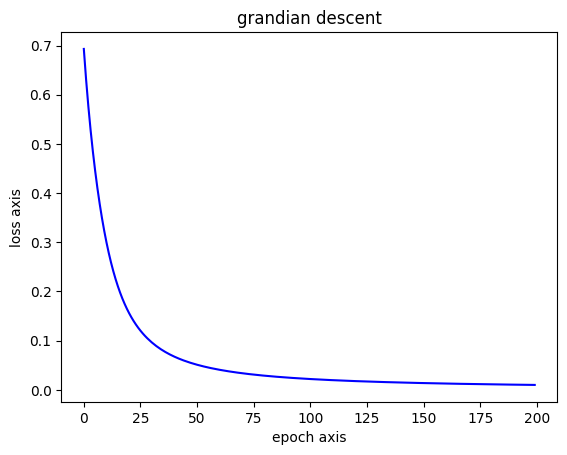

In [15]:
x = torch.tensor([[1.0, -1.0]])      # shape = [1, 2]
y_true_index = torch.tensor([1])         # 类别标签 1（第二类）

w1 = torch.tensor([[0.1, 0.2],
          [0.3, 0.4]], requires_grad=True)    # shape = [2, 2]

b1 = torch.tensor([0.0, 0.0], requires_grad=True)     # shape = [2]

w2 = torch.tensor([[ 0.1, -0.1],
          [-0.2,  0.2]], requires_grad=True)   # shape = [2, 2]

b2 = torch.tensor([0.0, 0.0], requires_grad=True)     # shape = [2]

model = SimpleNN(w1, w2, b1, b2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

losses = []
epochs = 200

for epoch in range(epochs):
  y_pred = model(x)

  loss = criterion(y_pred, y_true_index)
  losses.append(loss.item())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch%10 ==0:
    print(f"epoch:, {epoch+1}",
       f"loss:, {loss.item():.4f}")

with torch.no_grad():
  y_pred = torch.softmax(model(x), dim=1)

print("the predication value is:")
print(y_pred)

y_pred_index = torch.argmax(y_pred, dim=1)
print("the y_pred index is:")
print(y_pred_index)

print("the y_true index is:")
print(y_true_index)

plt.plot(range(epochs), losses, "blue")
plt.xlabel("epoch axis")
plt.ylabel("loss axis")
plt.title("grandian descent")
plt.show()